# TL2: Inteligencia Artificial - Sistemas Inteligentes

_Nota: en caso de que la ejecución de el notebook se haya limpiado, ver la versión en git: https://github.com/b-Tomas/ai-reports-dashbord-unc_

Implementa un sistema RAG en base a el Manual de Seguridad de la Universidad Nacional de Córdoba ([ver en PDF](https://drive.google.com/uc?export=download&id=1pAuwtHUkIg5dF35j6he-k5jzel6h3atk)) y un agente que lo consume como base conocimiento.

Además, se implementan herramientas para el manejo de reportes de incidentes (descritos en el propio manual) a través de un servicio implementado específicamente para este proyecto.

Este servicio tiene una interfaz web accesible desde https://ai-2026-tl2-reports-dashboard.netlify.app/. El acceso se realiza a través de single sing-on de Google Workspace utilizando un email de dominio @mi.unc.edu.ar o @unc.edu.ar.

El código fuente del proyecto se aloja en https://github.com/b-Tomas/ai-reports-dashbord-unc

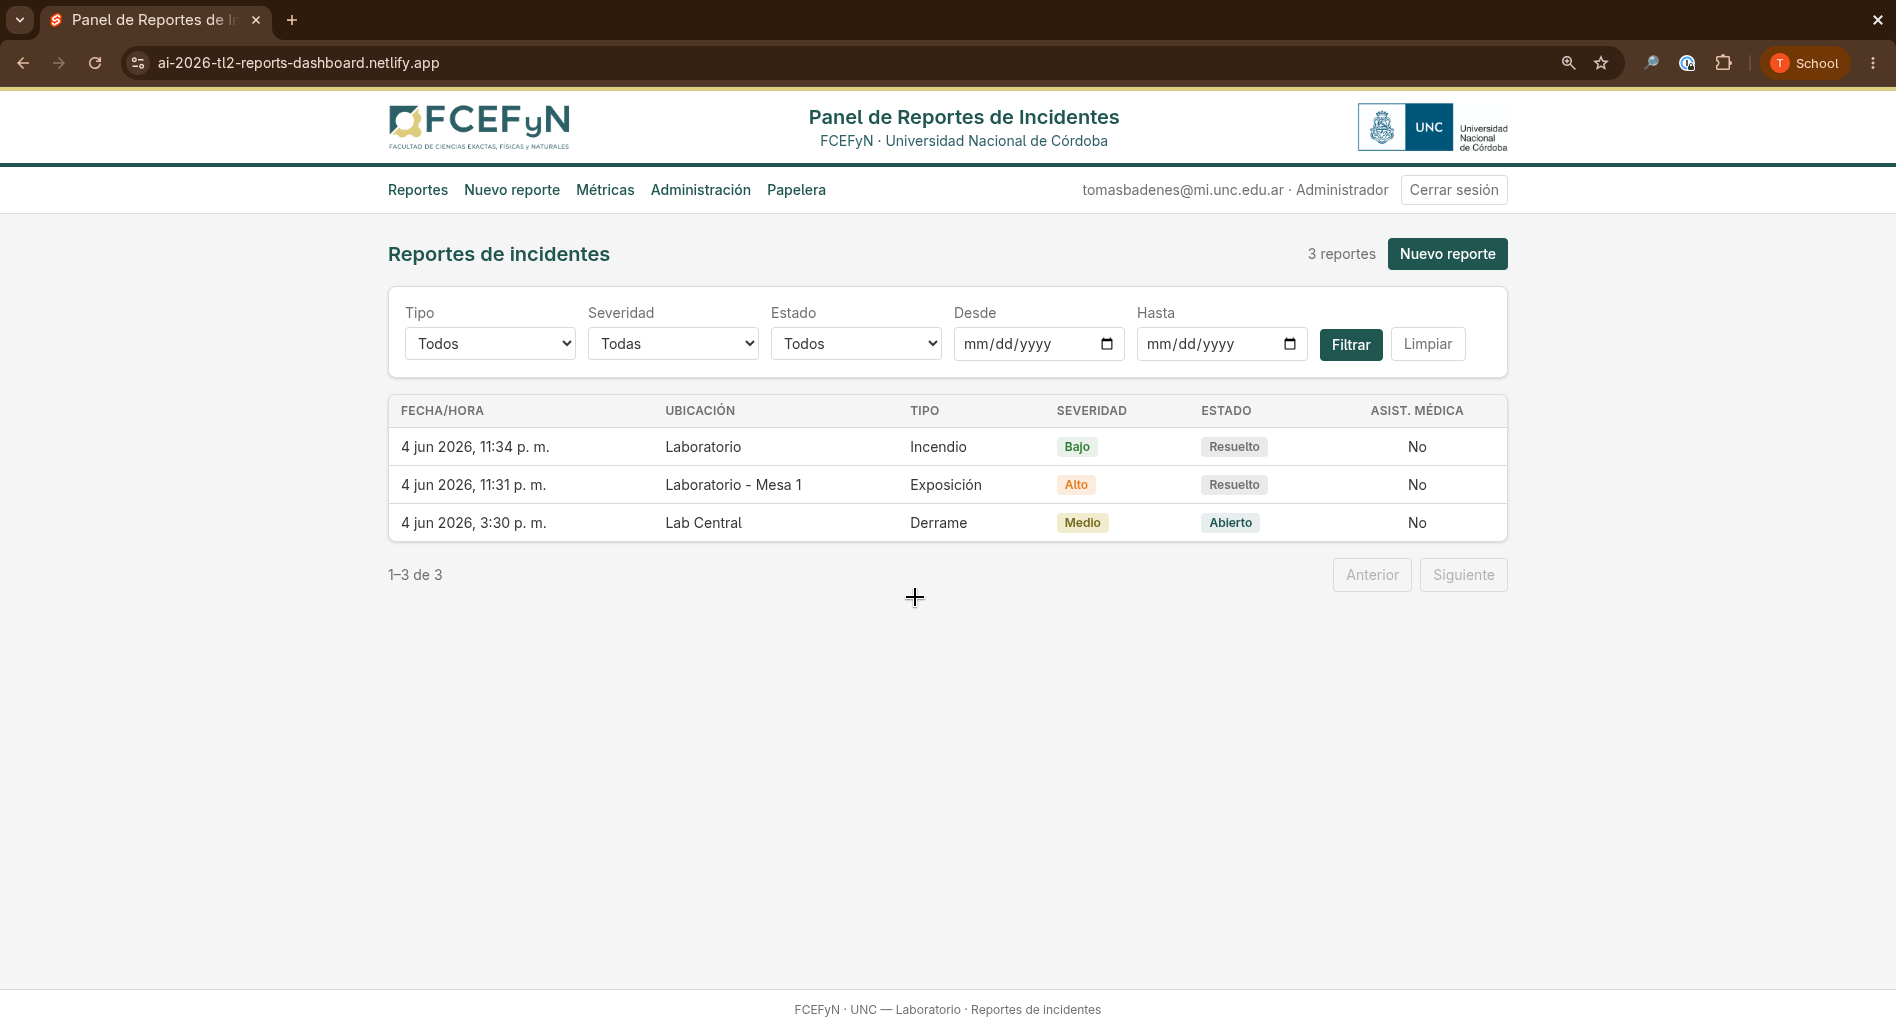

El dashboard expone acceso a incidentes registrados, permitiendo el registro, edicicón y eliminado de reportes. Además permite visualizar métricas de uso por API, representando las llamadas realizadas por el agente demostrado en este notebook.

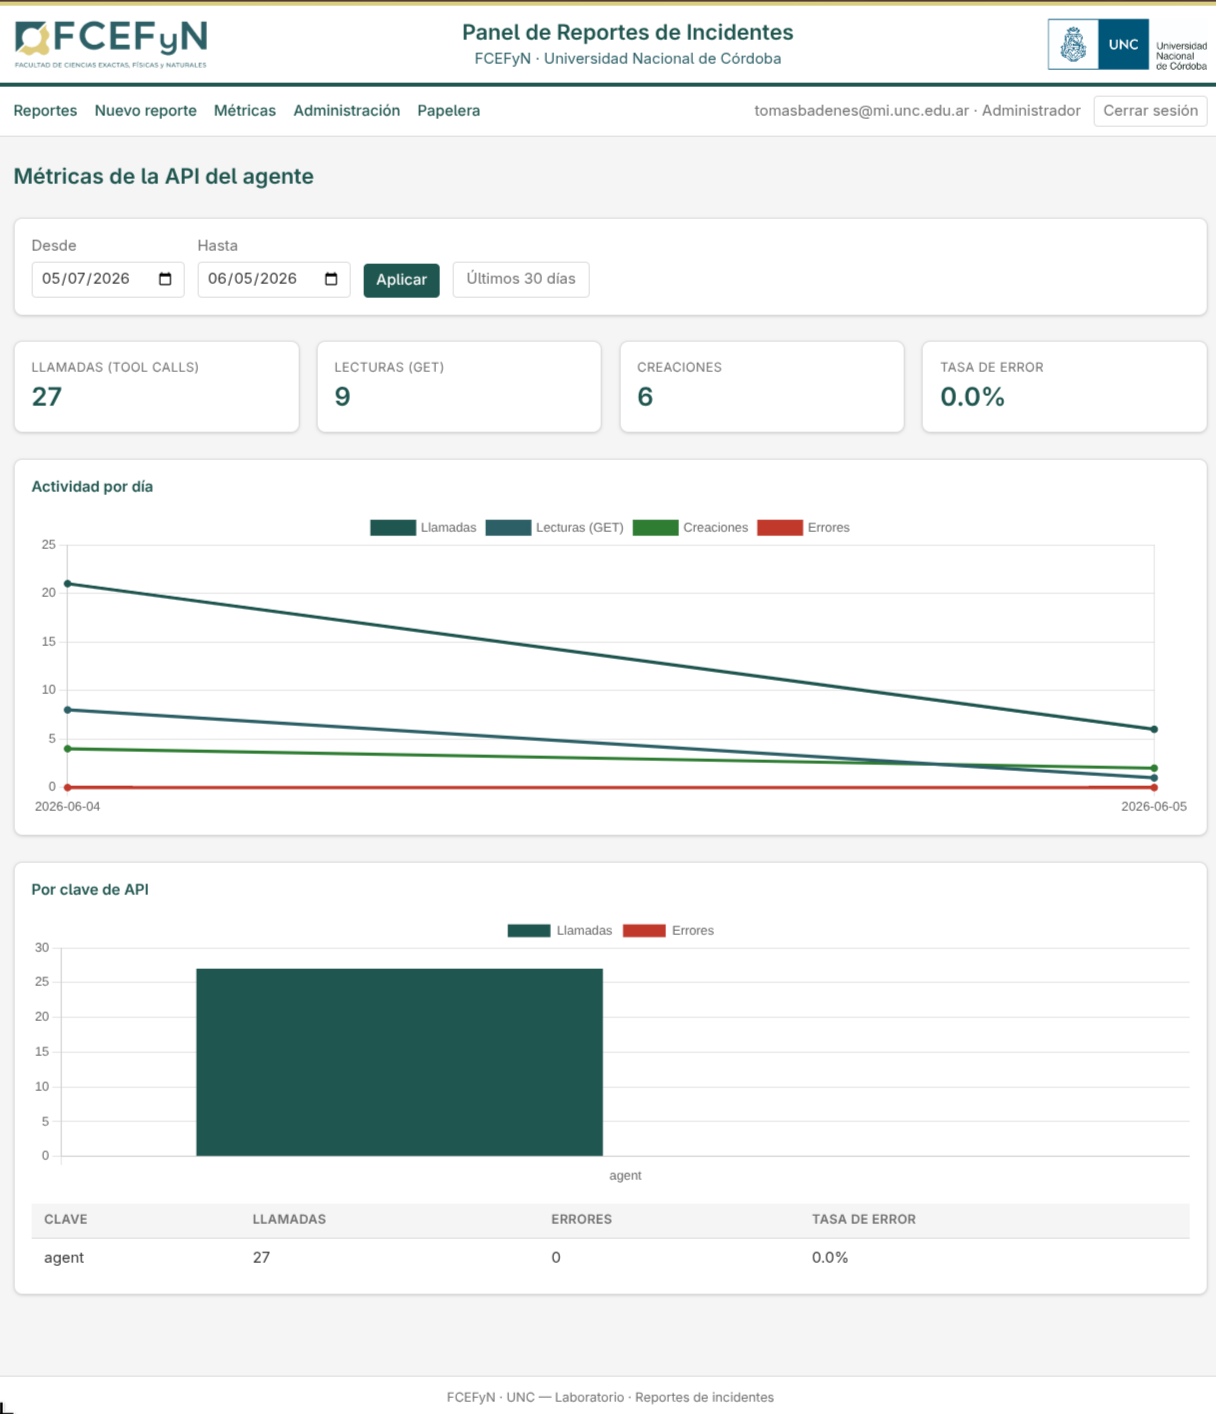

Para conectar un agente, generar una API key desde el panel de administración en [`/admin`](https://ai-2026-tl2-reports-dashboard.netlify.app/admin).

La aplicación web se _hostea_ en [Netlify](https://www.netlify.com/), y la base de datos en [Supabase](https://supabase.com/). Ambas plataformas son altamente recomendables para el desarrollo de MVPs o para pruebas de concepto, destacando en particular Supabase por proveer herramientas _built-in_ para manejo de usuarios y autenticación con integración nativa para Google SSO.



In [ ]:
%pip install -q "langchain==1.3.4" "langchain-core==1.4.0" "langchain-text-splitters==1.1.2" "langchain-groq==1.1.2" "langchain-huggingface==1.2.2" "langgraph==1.2.4" "groq==0.37.1" "pypdf==6.12.2" "sentence-transformers==5.5.1" "python-dotenv==1.2.2" "pydantic==2.13.4" "websockets==15.0.1" "requests==2.34.2"

import os
import json
from typing import Literal, Optional

import requests
from pypdf import PdfReader
from pydantic import BaseModel, Field
from dotenv import load_dotenv

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_core.tools.retriever import create_retriever_tool
from langchain.agents import create_agent
from langchain_core.messages import AIMessage, ToolMessage

from google.colab import userdata
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Creación de la base de conocimiento

Carga el manual de seguridad de la UNC (592kB, 53 páginas) en una base de datos vectorial utilizando un modelo de embeddings obtenido desde HugginFace.

In [ ]:
# PDF_PATH = "/content/drive/MyDrive/Inteligencia Artificial Grupo 7/TL2/Manual de seguridad UNC.pdf"
PDF_DOWNLOAD_URL = "https://drive.google.com/uc?export=download&id=1pAuwtHUkIg5dF35j6he-k5jzel6h3atk"
PDF_PATH = "./Manual de seguridad UNC.pdf" # Local path after download

# Download the PDF
response = requests.get(PDF_DOWNLOAD_URL)
response.raise_for_status() # Raise an exception for HTTP errors
with open(PDF_PATH, "wb") as f:
    f.write(response.content)

INDEX_PATH = "vector_store.json"
EMBEDDING_MODEL = "sentence-transformers/all-mpnet-base-v2"
LLM_MODEL = "openai/gpt-oss-120b"
CHUNK_SIZE = 1000
CHUNK_OVERLAP = 50
TOP_K = 5
LLM_MAX_TOKENS = 1024

# En local:
# load_dotenv()
# GROQ_API_KEY = os.getenv("GROQ_API_KEY")

# En colab
GROQ_API_KEY = userdata.get('GROQ_API_KEY')

llm = ChatGroq(
    model=LLM_MODEL,
    temperature=0,
    api_key=GROQ_API_KEY,
    max_tokens=LLM_MAX_TOKENS,
    max_retries=2,
)

embeddings = HuggingFaceEmbeddings(model_name=EMBEDDING_MODEL)

# Índice vectorial en memoria (langchain-core). Se persiste en INDEX_PATH para no
# reembeber el PDF en cada ejecución; si el archivo ya existe, se carga.
if os.path.exists(INDEX_PATH):
    vector_db = InMemoryVectorStore.load(INDEX_PATH, embeddings)
else:
    lector = PdfReader(PDF_PATH)
    documentos = [
        Document(page_content=p.extract_text() or "", metadata={"source": PDF_PATH, "page": i})
        for i, p in enumerate(lector.pages)
    ]
    chunks = RecursiveCharacterTextSplitter(
        chunk_size=CHUNK_SIZE, chunk_overlap=CHUNK_OVERLAP
    ).split_documents(documentos)
    vector_db = InMemoryVectorStore.from_documents(chunks, embeddings)
    vector_db.dump(INDEX_PATH)

retriever = vector_db.as_retriever(search_kwargs={"k": TOP_K})

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
herramienta_busqueda = create_retriever_tool(
    retriever,
    name="buscar_reglamento_unc",
    description=(
        "Busca en el Manual de Seguridad de la FCEFyN (UNC): normas de "
        "seguridad, protocolos y cuidados en los laboratorios."
    ),
)

## Integración con la API de Reportes de Incidentes

El agente lee y escribe reportes en el dashboard vía su API REST `/api/v1/incidents`
(`https://ai-2026-tl2-reports-dashboard.netlify.app`), autenticando con la clave emitida en el dashboard de admnistración (`/admin`):

Agregar al `.env`, junto a `GROQ_API_KEY`:

```
REPORTS_API_KEY=irk_<clave-emitida-en-/admin>
```

**Herramientas expuestas (CRUD completo):**

| Herramienta | Método + ruta | Uso |
| --- | --- | --- |
| `crear_incidente` | POST `/incidents` | Registra un reporte → 201 con `id` |
| `obtener_incidente` | GET `/incidents/{id}` | Lee un reporte (404 si no existe/eliminado) |
| `listar_incidentes` | GET `/incidents` | Filtra y pagina (excluye eliminados) |
| `actualizar_incidente` | PATCH `/incidents/{id}` | Update parcial (común: transición de `status`) |
| `eliminar_incidente` | DELETE `/incidents/{id}` | Soft-delete → 204 |

**Contrato de la API** (claves en inglés, valores enum en español):

- `timestamp` (ISO 8601 con offset, req.), `location` (req.),
- `incident_type`: `DERRAME | INCENDIO | EXPOSICION | FUGA_GAS`,
- `severity_level`: `BAJO | MEDIO | ALTO | CRITICO`,
- `status`: `ABIERTO | EN_PROGRESO | RESUELTO`,
- `chemicals_involved`: lista de `{name, hazard_class?, estimated_quantity?}` (default `[]`),
- `actions_taken`: lista de texto (mín. 1 elemento), `medical_assistance_required`: bool.

Campos de solo lectura devueltos: `id`, `created_at`, `updated_at`. Los errores tienen la
forma `{ "error": { "code", "message", "details"? } }`; en `422`, `details` lista los
campos inválidos para autocorrección del agente.

In [ ]:
REPORTS_API_BASE_URL = "https://ai-2026-tl2-reports-dashboard.netlify.app"
# REPORTS_API_KEY = os.getenv("REPORTS_API_KEY")
REPORTS_API_KEY = userdata.get('REPORTS_API_KEY')
API_TIMEOUT = 30

IncidentType = Literal["DERRAME", "INCENDIO", "EXPOSICION", "FUGA_GAS"]
SeverityLevel = Literal["BAJO", "MEDIO", "ALTO", "CRITICO"]
Status = Literal["ABIERTO", "EN_PROGRESO", "RESUELTO"]

In [ ]:
def _api_request(method, path, *, params=None, json_body=None):
    """Llama a /api/v1 con la API key. Devuelve el JSON de la API, o
    {'error': {code, message, details?}} ante un fallo."""
    url = f"{REPORTS_API_BASE_URL}/api/v1{path}"
    headers = {"Authorization": f"Bearer {REPORTS_API_KEY}"}
    try:
        r = requests.request(
            method, url, headers=headers, params=params, json=json_body, timeout=API_TIMEOUT
        )
    except requests.RequestException as e:
        return {"error": {"code": "network_error", "message": str(e)}}
    if r.status_code == 204:
        return {"ok": True, "status_code": 204}
    try:
        return r.json()
    except ValueError:
        return {"error": {"code": "non_json", "message": r.text[:500]}}


class Quimico(BaseModel):
    """Sustancia química involucrada en el incidente."""

    name: str = Field(description="Nombre del químico, ej. 'Ácido Acético Glacial'.")
    hazard_class: Optional[str] = Field(
        default=None, description="Clase de peligro según el manual, ej. 'Clase B y Clase E'."
    )
    estimated_quantity: Optional[str] = Field(
        default=None, description="Cantidad estimada, ej. '250 ml' o 'Desconocido'."
    )


def _quimicos_a_dicts(chemicals_involved):
    return [
        q.model_dump(exclude_none=True) if isinstance(q, Quimico) else q
        for q in chemicals_involved
    ]

@tool
def crear_incidente(
    timestamp: str,
    location: str,
    incident_type: IncidentType,
    severity_level: SeverityLevel,
    actions_taken: list[str],
    medical_assistance_required: bool,
    status: Status,
    chemicals_involved: Optional[list[Quimico]] = None,
) -> str:
    """Registra un nuevo reporte de incidente de laboratorio en el dashboard.

    Campos obligatorios:
    - timestamp: fecha-hora ISO 8601 CON offset de zona, ej. '2026-06-04T18:30:00Z'.
    - location: lugar, ej. 'Laboratorio Central - Mesa 4'.
    - incident_type: uno de DERRAME, INCENDIO, EXPOSICION, FUGA_GAS.
    - severity_level: uno de BAJO, MEDIO, ALTO, CRITICO.
    - actions_taken: lista de acciones tomadas (AL MENOS 1 elemento, texto no vacío).
    - medical_assistance_required: true/false.
    - status: uno de ABIERTO, EN_PROGRESO, RESUELTO.
    Opcional:
    - chemicals_involved: lista de químicos {name, hazard_class?, estimated_quantity?}.

    Devuelve el reporte creado (con id, created_at) o un error con 'details' por campo
    que debés usar para corregir y reintentar.
    """
    payload = {
        "timestamp": timestamp,
        "location": location,
        "incident_type": incident_type,
        "severity_level": severity_level,
        "actions_taken": actions_taken,
        "medical_assistance_required": medical_assistance_required,
        "status": status,
    }
    if chemicals_involved:
        payload["chemicals_involved"] = _quimicos_a_dicts(chemicals_involved)
    return json.dumps(_api_request("POST", "/incidents", json_body=payload), ensure_ascii=False)


@tool
def obtener_incidente(incident_id: str) -> str:
    """Obtiene un reporte de incidente por su id (UUID).

    Devuelve el reporte completo o un error 'not_found' si no existe o fue eliminado.
    """
    return json.dumps(_api_request("GET", f"/incidents/{incident_id}"), ensure_ascii=False)


@tool
def listar_incidentes(
    status: Optional[Status] = None,
    incident_type: Optional[IncidentType] = None,
    severity_level: Optional[SeverityLevel] = None,
    desde: Optional[str] = None,
    hasta: Optional[str] = None,
    limit: int = 25,
    offset: int = 0,
) -> str:
    """Lista reportes de incidentes con filtros y paginación. Excluye los eliminados.

    Filtros opcionales: status, incident_type, severity_level (mismos enums que crear_incidente),
    desde/hasta (rango de fechas ISO 8601, ej. '2026-01-01' o '2026-01-01T00:00:00Z').
    limit: máx 100 (default 25). offset: default 0.
    Devuelve {items, total, limit, offset}.
    """
    params = {
        "status": status,
        "incident_type": incident_type,
        "severity_level": severity_level,
        "from": desde,
        "to": hasta,
        "limit": limit,
        "offset": offset,
    }
    params = {k: v for k, v in params.items() if v is not None}
    return json.dumps(_api_request("GET", "/incidents", params=params), ensure_ascii=False)


@tool
def actualizar_incidente(
    incident_id: str,
    status: Optional[Status] = None,
    severity_level: Optional[SeverityLevel] = None,
    incident_type: Optional[IncidentType] = None,
    location: Optional[str] = None,
    timestamp: Optional[str] = None,
    actions_taken: Optional[list[str]] = None,
    medical_assistance_required: Optional[bool] = None,
    chemicals_involved: Optional[list[Quimico]] = None,
) -> str:
    """Actualiza parcialmente un reporte (PATCH). El caso común es la transición de
    status: ABIERTO -> EN_PROGRESO -> RESUELTO.

    Enviá solo los campos a cambiar; los omitidos conservan su valor actual.
    actions_taken, si se envía, debe tener >= 1 elemento.
    Devuelve el reporte actualizado o un error con 'details' por campo.
    """
    patch = {
        "status": status,
        "severity_level": severity_level,
        "incident_type": incident_type,
        "location": location,
        "timestamp": timestamp,
        "actions_taken": actions_taken,
        "medical_assistance_required": medical_assistance_required,
    }
    patch = {k: v for k, v in patch.items() if v is not None}
    if chemicals_involved is not None:
        patch["chemicals_involved"] = _quimicos_a_dicts(chemicals_involved)
    return json.dumps(
        _api_request("PATCH", f"/incidents/{incident_id}", json_body=patch), ensure_ascii=False
    )


@tool
def eliminar_incidente(incident_id: str) -> str:
    """Elimina (soft-delete) un reporte de incidente por id. La fila se conserva pero
    deja de aparecer en listados y consultas.

    Devuelve {ok: true, status_code: 204} o un error 'not_found'.
    """
    return json.dumps(_api_request("DELETE", f"/incidents/{incident_id}"), ensure_ascii=False)


herramientas = [
    herramienta_busqueda,
    crear_incidente,
    obtener_incidente,
    listar_incidentes,
    actualizar_incidente,
    eliminar_incidente,
]

In [ ]:
INSTRUCCIONES = (
    "Sos un asistente experto en seguridad y reglamentos de la FCEFyN, UNC. "
    "Usá 'buscar_reglamento_unc' para fundamentar las respuestas en el manual. "
    "Podés gestionar reportes de incidentes de laboratorio con las herramientas "
    "'crear_incidente', 'obtener_incidente', 'listar_incidentes', "
    "'actualizar_incidente' y 'eliminar_incidente'. Al registrar un incidente, fundamentá "
    "las 'actions_taken' en el manual (buscá con 'buscar_reglamento_unc') y usá los valores "
    "de enum exactos en español para incident_type, severity_level y status. Si una operación "
    "devuelve un error con 'details', leé esos detalles para corregir los campos y reintentar. "
    "Respondé en español, de forma clara y citando el reglamento cuando corresponda."
)

agente = create_agent(llm, herramientas, system_prompt=INSTRUCCIONES)

In [ ]:
preguntas = [
    "¿Qué precauciones hay que tener al manipular sustancias corrosivas?",
    "¿Cómo se debe actuar ante un derrame de un producto químico en el laboratorio?",
]

for pregunta in preguntas:
    resultado = agente.invoke({"messages": [{"role": "user", "content": pregunta}]})
    print("P:", pregunta)
    print("R:", resultado["messages"][-1].content, "\n")

P: ¿Qué precauciones hay que tener al manipular sustancias corrosivas?
R: **Precauciones al manipular sustancias corrosivas**  
(Según el Manual de Seguridad de la FCEFyN – UNC, sección *“Manejo seguro de productos controlados”* y apartado *12 – Equipo de Protección Personal*).

| Acción | Por qué es necesaria |
|--------|----------------------|
| **Utilizar Equipo de Protección Personal (EPP) completo**: guantes resistentes a químicos, gafas o pantalla facial, bata o delantal de laboratorio y, cuando sea necesario, protección para los pies. | Evita contacto directo con la piel y los ojos, que pueden sufrir quemaduras graves. |
| **Trabajar bajo campana extractora o cabina química**. | Contiene vapores y salpicaduras, reduciendo la exposición del personal y del ambiente. |
| **Usar envases secundarios** (recipientes de seguridad) para el transporte y almacenamiento. | Minimiza el riesgo de derrames y roturas del envase original. |
| **Emplear la concentración más baja posible** y, siem

In [ ]:
def mostrar_traza(resultado):
    """Imprime las llamadas a herramientas (con sus respuestas) y la respuesta final."""
    for msg in resultado["messages"]:
        if isinstance(msg, AIMessage) and msg.tool_calls:
            for tc in msg.tool_calls:
                print(f"  🔧 {tc['name']}({json.dumps(tc['args'], ensure_ascii=False)})")
        elif isinstance(msg, ToolMessage):
            print(f"  ↳ {msg.name}: {msg.content[:300]}")
    print("R:", resultado["messages"][-1].content)


demos = [
    # Ciclo de vida en una ejecución: crear -> EN_PROGRESO -> RESUELTO -> obtener -> eliminar.
    "Registrá un incidente: derrame de Ácido Clorhídrico (~500 ml) en el "
    "'Laboratorio Central - Mesa 2', ocurrido el 4 de Junio de 2026, severidad ALTO. "
    "Acciones: se evacuó el área inmediata y se neutralizó con material adsorbente. "
    "No requirió asistencia médica. Crealo en estado ABIERTO. "
    "Luego transicioná ese mismo incidente a EN_PROGRESO y después a RESUELTO, "
    "mostrame el reporte final y, por último, eliminalo. Confirmá cada paso con su id.",
    # Listar incidentes existentes y producir insights
    "Listá los incidentes de tipo DERRAME, mostrando cuántos hay en total. En base al "
    "manual de la UNC, fueron manejados correctamente?",
]

for pregunta in demos:
    print("P:", pregunta)
    resultado = agente.invoke({"messages": [{"role": "user", "content": pregunta}]})
    mostrar_traza(resultado)
    print()

P: Registrá un incidente: derrame de Ácido Clorhídrico (~500 ml) en el 'Laboratorio Central - Mesa 2', ocurrido el 4 de Junio de 2026, severidad ALTO. Acciones: se evacuó el área inmediata y se neutralizó con material adsorbente. No requirió asistencia médica. Crealo en estado ABIERTO. Luego transicioná ese mismo incidente a EN_PROGRESO y después a RESUELTO, mostrame el reporte final y, por último, eliminalo. Confirmá cada paso con su id.
  🔧 buscar_reglamento_unc({"query": "derrame ácido clorhídrico procedimiento neutralizar adsorbente"})
  ↳ buscar_reglamento_unc: • Debe utilizarse elementos de protección personal al neutraliz ar un derramamiento corrosivo 
extenso, como guantes, botas, delantal y los dispos itivos apropiados para la protección ocular. 
Se requiere protección respiratoria si hay emisión de líquidos, vapores o gases corrosivos.  
• Si se requi
  🔧 crear_incidente({"actions_taken": ["Se evacuó el área inmediata", "Se neutralizó con material adsorbente según el procedim